<class 'pandas.core.frame.DataFrame'>
Int64Index: 48760 entries, 0 to 65534
Data columns (total 52 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   latitude             48760 non-null  float64
 1   longitude            48760 non-null  float64
 2   node_id              48760 non-null  int64  
 3   segment_id           48760 non-null  int64  
 4   highway              48760 non-null  object 
 5   geohash              48760 non-null  object 
 6   geohash_crash_count  48760 non-null  int64  
 7   node_lat             48760 non-null  float64
 8   node_lon             48760 non-null  float64
 9   last_junction        48760 non-null  int64  
 10  next_junction        48760 non-null  int64  
 11  mini_roundabout      48760 non-null  int64  
 12  crossing             48760 non-null  int64  
 13  traffic_signals      48760 non-null  int64  
 14  give_way             48760 non-null  int64  
 15  stop                 48760 non-null 

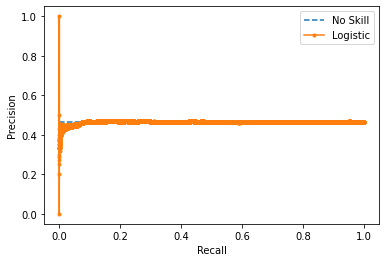

roc curve and auc:
No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.497


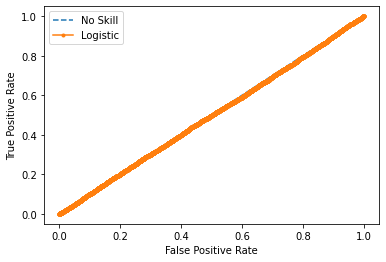

Runtime of the program is 17.26294779777527


In [13]:
import time
# starting time
start = time.time()
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
# precision-recall curve and f1
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc

# roc curve and auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from matplotlib import pyplot

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# load data
dataset = pd.read_excel ('/content/Data set.csv')
dataset = dataset.dropna()
print(dataset.info())
dataset.head()
# split data into X and y
X = dataset.iloc[:, 0: -1].values
y = dataset.iloc[:, -1].values
from sklearn.preprocessing import LabelEncoder
LE1 = LabelEncoder()
X[:,4] = np.array(LE1.fit_transform(X[:,4]))
LE2 = LabelEncoder()
X[:,5] = np.array(LE2.fit_transform(X[:,5]))
LE3 = LabelEncoder()
X[:,32] = np.array(LE3.fit_transform(X[:,32]))
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct =ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[45])],remainder="passthrough")
X = np.array(ct.fit_transform(X))
# split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)



from xgboost import XGBClassifier
regressor = XGBClassifier(n_estimators=80, random_state=0)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

# evaluate predictions

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Accident risk : ", accuracy_score(y_test, y_pred))


# precision-recall curve and f1
print("precision-recall curve and f1:")
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_test)
# predict probabilities
lr_probs = model.predict_proba(X_train)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
# predict class values
yhat = model.predict(X_train)
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_probs)
lr_f1, lr_auc = f1_score(y_test, yhat), auc(lr_recall, lr_precision)
# summarize scores
print('Logistic: f1=%.3f auc=%.3f' % (lr_f1, lr_auc))
# plot the precision-recall curves
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
pyplot.plot(lr_recall, lr_precision, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# roc curve and auc
print("roc curve and auc:")
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(y_test))]
# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_test)
# predict probabilities
lr_probs = model.predict_proba(X_train)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
# calculate scores
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# Hyperparameter code
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# load data
dataset = pd.read_excel ('/Data set.csv')
dataset = dataset.dropna()
print(dataset.info())
dataset.head()
# split data into X and y
X = dataset.iloc[:, 0: -1].values
y = dataset.iloc[:, -1].values
from sklearn.preprocessing import LabelEncoder
LE1 = LabelEncoder()
X[:,4] = np.array(LE1.fit_transform(X[:,4]))
LE2 = LabelEncoder()
X[:,5] = np.array(LE2.fit_transform(X[:,5]))
LE3 = LabelEncoder()
X[:,32] = np.array(LE3.fit_transform(X[:,32]))
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct =ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[45])],remainder="passthrough")
X = np.array(ct.fit_transform(X))
# split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)
import xgboost as xgb

def xgb_classifier(n_estimators, max_depth, reg_alpha,
                   reg_lambda, min_child_weight, num_boost_round,
                   gamma):
    params = {"booster": 'gbtree',
              "objective" : "binary:logistic",
              "eval_metric" : "auc", 
              "is_unbalance": True,
              "n_estimators": int(n_estimators),
              "max_depth" : int(max_depth),
              "reg_alpha" : reg_alpha,
              "reg_lambda" : reg_lambda,
              "gamma": gamma,
              "num_threads" : 20,
              "min_child_weight" : int(min_child_weight),
              "learning_rate" : 0.01,
              "subsample_freq" : 5,
              "seed" : 42,
              "verbosity" : 0,
              "num_boost_round": int(num_boost_round)}
    train_data = xgb.DMatrix(X_train, y_train)
    cv_result = xgb.cv(params,
                       train_data,
                       1000,
                       early_stopping_rounds=100,
                       stratified=True,
                       nfold=3)
    return cv_result['test-auc-mean'].iloc[-1]

import lightgbm
def lgb_classifier(num_boost_round, num_leaves, max_depth, 
                   lambda_l2, lambda_l1, min_child_samples, 
                   min_data_in_leaf):
    params = {"boosting_type": 'gbdt',
              "objective" : "binary",
              "metric" : "auc", 
              "is_unbalance": True,
              "num_leaves" : int(num_leaves),
              "max_depth" : int(max_depth),
              "lambda_l2" : lambda_l2,
              "lambda_l1" : lambda_l1,
              "num_threads" : 20,
              "min_child_samples" : int(min_child_samples),
              "min_data_in_leaf": int(min_data_in_leaf),
              "learning_rate" : 0.01,
              "subsample_freq" : 5,
              "bagging_seed" : 42,
              "verbosity" : -1,
              "num_boost_round": int(num_boost_round)}
    train_data = lightgbm.Dataset(X_train, y_train, categorical_feature=categorical_features)
    cv_result = lightgbm.cv(params,
                       train_data,
                       1000,
                       early_stopping_rounds=100,
                       stratified=True,
                       nfold=3)
    return cv_result['auc-mean'][-1]
!pip install bayesian-optimization

from bayes_opt import BayesianOptimization
xgbBO = BayesianOptimization(xgb_classifier, {  "n_estimators": (10, 100),
                                                'max_depth': (5, 40),
                                                'reg_alpha': (0.0, 0.1),
                                                'reg_lambda': (0.0, 0.1),
                                                'min_child_weight': (1, 10),
                                                'num_boost_round': (100, 1000),
                                                "gamma": (0, 10)
                                                })

xgbBO.maximize(n_iter=15, init_points=2)



# end time
end = time.time()

# total time taken
print(f"Runtime of the program is {end - start}")